In [53]:
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv')  
dat_wa = pd.read_csv('C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\data_with_wa_scores.csv', sep=',')


In [54]:
disziplin = "Speerwurf"
gender = "M"
altersklasse = "Maenner"
filtered_data = data[(data["disziplin"] == disziplin) & (data["geschlecht"] == gender) & (data["altersklasse"] == altersklasse)]
filtered_data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
5452,2005,M,Maenner,Speerwurf,84.88,NaN,Mark Frank,1977,1.LAV Rostock,04.09.,Berlin
5453,2005,M,Maenner,Speerwurf,83.2,NaN,Christian Nicolay,1976,TV Wattenscheid 01,29.05.,Zeulenroda
5454,2005,M,Maenner,Speerwurf,83.07,NaN,Stefan Wenk,1981,VfB Stuttgart,12.02.,Sindelfingen
5455,2005,M,Maenner,Speerwurf,81.47,NaN,Bjoern Lange,1979,SC Magdeburg,12.07.,Berlin
5456,2005,M,Maenner,Speerwurf,81.01,NaN,Manuel Nau,1977,SC Charlottenburg Berlin,10.09.,Gengenbach


In [55]:
filtered_data["alter"] = filtered_data["jahr"] - filtered_data["geburtsjahr"]
filtered_data

C:\Users\Mattis\AppData\Local\Temp\ipykernel_12140\3901908887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["alter"] = filtered_data["jahr"] - filtered_data["geburtsjahr"]


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,alter
5452,2005,M,Maenner,Speerwurf,84.88,NaN,Mark Frank,1977,1.LAV Rostock,04.09.,Berlin,28
5453,2005,M,Maenner,Speerwurf,83.2,NaN,Christian Nicolay,1976,TV Wattenscheid 01,29.05.,Zeulenroda,29
5454,2005,M,Maenner,Speerwurf,83.07,NaN,Stefan Wenk,1981,VfB Stuttgart,12.02.,Sindelfingen,24
5455,2005,M,Maenner,Speerwurf,81.47,NaN,Bjoern Lange,1979,SC Magdeburg,12.07.,Berlin,26
5456,2005,M,Maenner,Speerwurf,81.01,NaN,Manuel Nau,1977,SC Charlottenburg Berlin,10.09.,Gengenbach,28
...,...,...,...,...,...,...,...,...,...,...,...,...
208297,2023,M,Maenner,Speerwurf,60.29,NaN,Martin Erle,1985,TSG Bruchsal,23.04.2023,Bruchsal,38
208298,2023,M,Maenner,Speerwurf,60.19,NaN,Jan Ruhrmann,1997,LAV Bayer Uerdingen/Dormagen,22.04.2023,Leichlingen,26
208299,2023,M,Maenner,Speerwurf,60.16,NaN,Niklas Ebinger,1998,LG Steinlach-Zollern,08.07.2023,Stuttgart,25
208300,2023,M,Maenner,Speerwurf,60.15,NaN,Amadeus Graeber,2005,SV Leonardo-da-Vinci Nauen,10.08.2023,Jerusalem (ISR),18


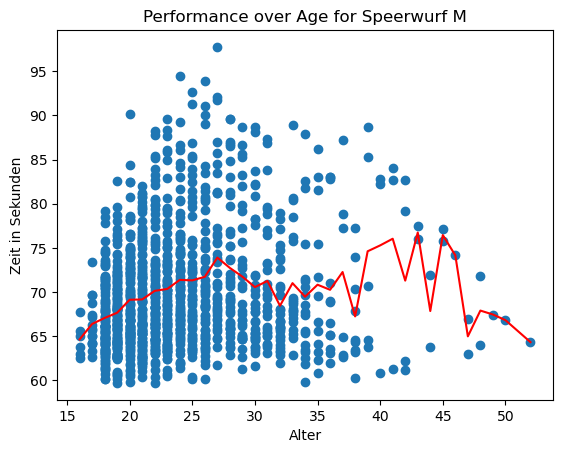

In [56]:
# exclude data points with time latger 2500 seconds
#filtered_data = filtered_data[filtered_data["leistung"] > 3000]
#plot all data points but per alter on x axis
# with the mean per alter as line
# exlude time less than 500 seconds
#filtered_data = filtered_data[(filtered_data["leistung"] > 500)]
plt.scatter(filtered_data["alter"], filtered_data["leistung"])
mean_per_alter = filtered_data.groupby("alter")["leistung"].mean().reset_index()
plt.plot(mean_per_alter["alter"], mean_per_alter["leistung"], color='red')
plt.xlabel("Alter")
plt.ylabel("Zeit in Sekunden")
plt.title(f"Performance over Age for {disziplin } {gender}")
plt.show()

In [57]:
# Print performances with times less than 795 seconds
print(filtered_data[filtered_data["leistung"] < 800])

        jahr geschlecht altersklasse  disziplin leistung wind  \
5452    2005          M      Maenner  Speerwurf    84.88  NaN   
5453    2005          M      Maenner  Speerwurf     83.2  NaN   
5454    2005          M      Maenner  Speerwurf    83.07  NaN   
5455    2005          M      Maenner  Speerwurf    81.47  NaN   
5456    2005          M      Maenner  Speerwurf    81.01  NaN   
...      ...        ...          ...        ...      ...  ...   
208297  2023          M      Maenner  Speerwurf    60.29  NaN   
208298  2023          M      Maenner  Speerwurf    60.19  NaN   
208299  2023          M      Maenner  Speerwurf    60.16  NaN   
208300  2023          M      Maenner  Speerwurf    60.15  NaN   
208301  2023          M      Maenner  Speerwurf    60.12  NaN   

                     name  geburtsjahr                        verein  \
5452           Mark Frank         1977                 1.LAV Rostock   
5453    Christian Nicolay         1976            TV Wattenscheid 01   
545